<a href="https://colab.research.google.com/github/johnxavier10k/fintech-complaints-product-analysis/blob/main/notebooks/01_data_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fintech Consumer Complaints: Data Validation

**Dataset:** CFPB Consumer Complaint Database  
**Scope:** Money transfer, virtual currency, or money services  
**Period:** January–December 2025  
**Objective:** Validate the dataset before cleaning and analysis.

In [13]:
from google.colab import files

uploaded = files.upload()

Saving fintech_complaints_raw.csv to fintech_complaints_raw (2).csv


In [14]:
import pandas as pd

df = pd.read_csv(
    "/content/fintech_complaints_raw.csv",
    low_memory=False
)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 84619
Columns: 16


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2025-10-07T12:25:20.000Z,"Money transfer, virtual currency, or money ser...",Domestic (US) money transfer,Other transaction problem,NaN,I am writing to formally express my concerns r...,NaN,Chime Financial Inc,GA,30240,NaN,Web,2025-10-07T12:30:36.000Z,Closed with explanation,Yes,16424004
1,2025-10-07T13:05:20.000Z,"Money transfer, virtual currency, or money ser...",Domestic (US) money transfer,Other transaction problem,NaN,I am writing to formally express my concerns r...,NaN,Chime Financial Inc,PA,19140,NaN,Web,2025-10-07T13:24:38.000Z,Closed with explanation,Yes,16423617
2,2025-10-07T13:13:23.000Z,"Money transfer, virtual currency, or money ser...",Mobile or digital wallet,Trouble accessing funds in your mobile or digi...,NaN,"XXXX hours ago ( XX/XX/year> ), I sent 2 payme...",NaN,"Paypal Holdings, Inc",IN,465XX,NaN,Web,2025-10-07T13:19:32.000Z,Closed with explanation,Yes,16423593
3,2025-10-07T13:28:38.000Z,"Money transfer, virtual currency, or money ser...",Domestic (US) money transfer,Other transaction problem,NaN,I am writing to formally express my concerns r...,NaN,Chime Financial Inc,TN,37072,NaN,Web,2025-10-07T13:46:56.000Z,Closed with explanation,Yes,16422359
4,2025-10-07T14:08:10.000Z,"Money transfer, virtual currency, or money ser...",Domestic (US) money transfer,Other transaction problem,NaN,I am writing to formally express my concerns r...,NaN,Chime Financial Inc,MS,39120,NaN,Web,2025-10-07T14:16:02.000Z,Closed with explanation,Yes,16421739


In [15]:
validation_summary = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique()
})

validation_summary

,data_type,missing_count,missing_percent,unique_values
Date received,object,0,0.00,81893
Product,object,0,0.00,1
Sub-product,object,0,0.00,7
Issue,object,0,0.00,16
Sub-issue,float64,84619,100.00,0
Consumer complaint narrative,object,19756,23.35,40547
Company public response,object,79224,93.62,10
Company,object,0,0.00,464
State,object,1253,1.48,59
ZIP code,object,0,0.00,9567


In [16]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate complaint IDs:", df["Complaint ID"].duplicated().sum())

Duplicate rows: 0
Duplicate complaint IDs: 0


## Cleaning decisions

- Remove `Sub-issue` because it is entirely empty.
- Retain records without complaint narratives because their categorical fields remain useful.
- Retain missing public responses and tags rather than treating them as data errors.
- Standardize column names for easier Python and SQL analysis.
- Convert date fields from text into datetime values.

In [17]:
# Preserve the original dataframe
df_clean = df.copy()

# Convert column names to lowercase snake_case
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

# Remove the completely empty column
df_clean = df_clean.drop(columns=["sub_issue"])

# Convert text dates into datetime values
df_clean["date_received"] = pd.to_datetime(
    df_clean["date_received"],
    errors="coerce",
    utc=True
)

df_clean["date_sent_to_company"] = pd.to_datetime(
    df_clean["date_sent_to_company"],
    errors="coerce",
    utc=True
)

print("Cleaned shape:", df_clean.shape)
print("Invalid received dates:", df_clean["date_received"].isna().sum())
print("Invalid sent dates:", df_clean["date_sent_to_company"].isna().sum())

df_clean.dtypes

Cleaned shape: (84619, 15)
Invalid received dates: 0
Invalid sent dates: 0


,0
date_received,"datetime64[ns, UTC]"
product,object
sub_product,object
issue,object
consumer_complaint_narrative,object
company_public_response,object
company,object
state,object
zip_code,object
tags,object


## Feature engineering

The following fields support time, channel, and response analysis:

- `received_month`: month in which CFPB received the complaint.
- `received_day`: day of the week the complaint was received.
- `routing_delay_hours`: time CFPB took to send the complaint to the company. This is not company resolution time.
- `has_narrative`: whether the consumer shared a written complaint.
- `has_public_response`: whether the company published a public response.
- `is_timely`: whether CFPB classified the company response as timely.

In [18]:
# Time-based features
df_clean["received_month"] = (
    df_clean["date_received"]
    .dt.strftime("%Y-%m")
)

df_clean["received_day"] = (
    df_clean["date_received"]
    .dt.day_name()
)

# Time between CFPB receipt and sending the complaint to the company
df_clean["routing_delay_hours"] = (
    df_clean["date_sent_to_company"] - df_clean["date_received"]
).dt.total_seconds() / 3600

# Availability indicators
df_clean["has_narrative"] = (
    df_clean["consumer_complaint_narrative"]
    .notna()
    .astype(int)
)

df_clean["has_public_response"] = (
    df_clean["company_public_response"]
    .notna()
    .astype(int)
)

# Convert Yes/No into 1/0
df_clean["is_timely"] = (
    df_clean["timely_response"]
    .map({"Yes": 1, "No": 0})
)

In [19]:
print("New shape:", df_clean.shape)
print("Negative routing delays:", (df_clean["routing_delay_hours"] < 0).sum())
print("Missing timely-response values:", df_clean["is_timely"].isna().sum())

df_clean[
    [
        "received_month",
        "received_day",
        "routing_delay_hours",
        "has_narrative",
        "has_public_response",
        "is_timely"
    ]
].head()

New shape: (84619, 21)
Negative routing delays: 0
Missing timely-response values: 0


,received_month,received_day,routing_delay_hours,has_narrative,has_public_response,is_timely
0,2025-10,Tuesday,0.087778,1,0,1
1,2025-10,Tuesday,0.321667,1,0,1
2,2025-10,Tuesday,0.102500,1,0,1
3,2025-10,Tuesday,0.305000,1,0,1
4,2025-10,Tuesday,0.131111,1,0,1


In [20]:
routing_summary = (
    df_clean["routing_delay_hours"]
    .describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99])
    .round(2)
)

routing_summary

,routing_delay_hours
count,84619.00
mean,22.36
std,155.59
min,0.02
50%,0.27
75%,0.47
90%,21.25
95%,55.68
99%,715.02
max,7177.24


### Routing-delay treatment

The distribution is highly right-skewed. Most complaints were routed quickly, while a small number experienced substantial delays. These values are retained because they may represent genuine operational exceptions. Median and percentile statistics will be used instead of the mean when describing typical performance.

In [21]:
df_clean["routing_delay_bucket"] = pd.cut(
    df_clean["routing_delay_hours"],
    bins=[0, 1, 24, 168, 720, float("inf")],
    labels=[
        "Under 1 hour",
        "1–24 hours",
        "1–7 days",
        "7–30 days",
        "Over 30 days"
    ],
    right=False,
    include_lowest=True
)

routing_bucket_summary = (
    df_clean["routing_delay_bucket"]
    .value_counts(sort=False)
    .to_frame("complaint_count")
)

routing_bucket_summary["percentage"] = (
    routing_bucket_summary["complaint_count"]
    / len(df_clean)
    * 100
).round(2)

routing_bucket_summary

,complaint_count,percentage
routing_delay_bucket,,
Under 1 hour,73713,87.11
1–24 hours,2783,3.29
1–7 days,5944,7.02
7–30 days,1336,1.58
Over 30 days,843,1.00


## Validation conclusion

The dataset contains 84,619 unique complaints and 15 usable original fields after removing the entirely empty `Sub-issue` column. No duplicate complaint IDs or invalid dates were found.

Routing time is highly right-skewed. While 87.11% of complaints were sent to companies within one hour, 9.60% took longer than one day and 843 complaints took over 30 days. These longer delays were retained because they may represent genuine operational exceptions.

The dataset is suitable for complaint-volume, issue, company-response, channel, and routing analysis. It cannot measure company resolution time because no resolution timestamp is provided.

In [22]:
sub_product_summary = (
    df_clean.groupby("sub_product", observed=True)
    .agg(complaint_count=("complaint_id", "count"))
    .sort_values("complaint_count", ascending=False)
    .reset_index()
)

sub_product_summary["percentage"] = (
    sub_product_summary["complaint_count"]
    / sub_product_summary["complaint_count"].sum()
    * 100
).round(2)

sub_product_summary

,sub_product,complaint_count,percentage
0,Domestic (US) money transfer,57855,68.37
1,Mobile or digital wallet,17150,20.27
2,Virtual currency,5535,6.54
3,International money transfer,2387,2.82
4,"Money order, traveler's check or cashier's check",911,1.08
5,Check cashing service,510,0.60
6,Foreign currency exchange,271,0.32


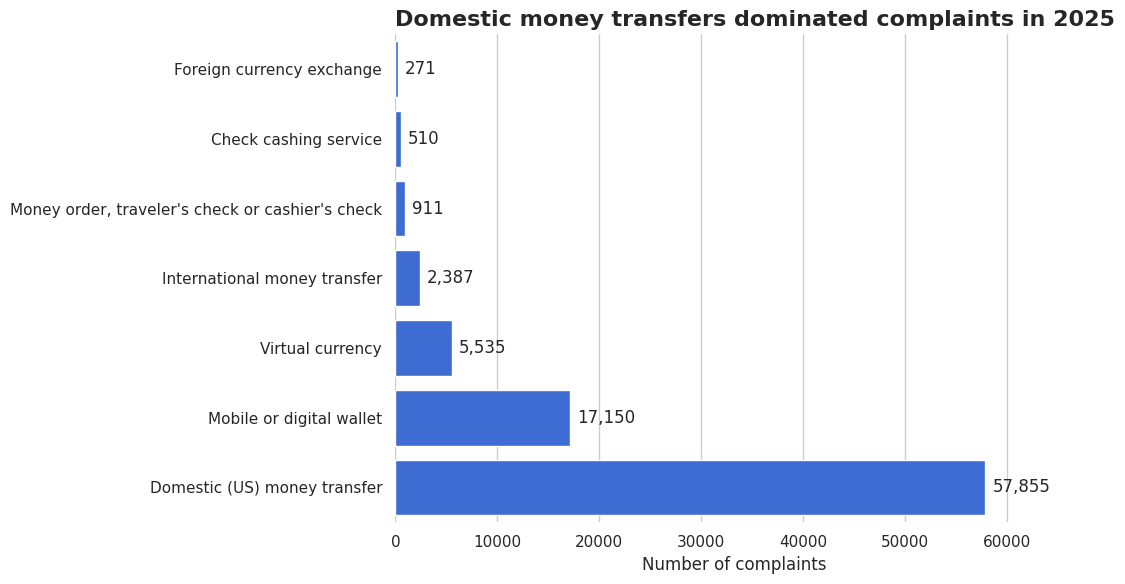

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

chart_data = sub_product_summary.sort_values(
    "complaint_count",
    ascending=True
)

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=chart_data,
    x="complaint_count",
    y="sub_product",
    color="#2563EB",
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{value:,.0f}"
            for value in chart_data["complaint_count"]
        ],
        padding=5
    )

ax.set_title(
    "Domestic money transfers dominated complaints in 2025",
    fontsize=16,
    fontweight="bold",
    loc="left"
)

ax.set_subtitle = None
ax.set_xlabel("Number of complaints")
ax.set_ylabel("")
ax.set_xlim(0, chart_data["complaint_count"].max() * 1.15)

sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.savefig(
    "sub_product_complaints_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Finding

Domestic money transfers represented 68.37% of complaints in the selected dataset. Mobile or digital wallets were the second-largest category at 20.27%, while virtual currency accounted for 6.54%.

Together, mobile/digital wallets and virtual currency represented 26.81% of complaints. Complaint volume alone does not establish product quality because customer and transaction volumes are unavailable.

## Mobile and digital wallet analysis

Mobile and digital wallets accounted for 17,150 complaints, making them the second-largest sub-product category. The next analysis identifies the problems most frequently reported within this segment.

In [24]:
wallet_df = df_clean[
    df_clean["sub_product"] == "Mobile or digital wallet"
].copy()

wallet_issue_summary = (
    wallet_df.groupby("issue")
    .agg(complaint_count=("complaint_id", "count"))
    .sort_values("complaint_count", ascending=False)
    .reset_index()
)

wallet_issue_summary["percentage"] = (
    wallet_issue_summary["complaint_count"]
    / len(wallet_df)
    * 100
).round(2)

print("Mobile/digital wallet complaints:", len(wallet_df))

wallet_issue_summary

Mobile/digital wallet complaints: 17150


,issue,complaint_count,percentage
0,Unauthorized transactions or other transaction...,5758,33.57
1,Fraud or scam,4981,29.04
2,Trouble accessing funds in your mobile or digi...,3038,17.71
3,"Managing, opening, or closing your mobile wall...",1773,10.34
4,Confusing or missing disclosures,771,4.50
5,Confusing or misleading advertising or marketing,290,1.69
6,Unexpected or other fees,280,1.63
7,Problem adding money,195,1.14
8,"Overdraft, savings, or rewards features",64,0.37
